In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('ab_testing.csv')


print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (5000, 7)

Column names:
['User ID', 'Group', 'Page Views', 'Time Spent', 'Conversion', 'Device', 'Location']

First 5 rows:


,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [3]:
# Rename columns for easier referencing
df.columns = ['user_id', 'group', 'page_views', 'time_spent', 'conversion', 'device', 'location']

# Convert conversion to binary
df['converted'] = df['conversion'].map({'Yes': 1, 'No': 0})

# Confirm
print("Column names updated:")
print(df.columns.tolist())
print(f"\nConversion value counts (original):")
print(df['conversion'].value_counts())
print(f"\nConverted column check:")
print(df['converted'].value_counts())
print(f"\nAny nulls?")
print(df.isnull().sum())

Column names updated:
['user_id', 'group', 'page_views', 'time_spent', 'conversion', 'device', 'location', 'converted']

Conversion value counts (original):
conversion
No     4515
Yes     485
Name: count, dtype: int64

Converted column check:
converted
0    4515
1     485
Name: count, dtype: int64

Any nulls?
user_id       0
group         0
page_views    0
time_spent    0
conversion    0
device        0
location      0
converted     0
dtype: int64


In [4]:
# --- Sanity Check 1: Group sizes and split ratio ---
group_counts = df['group'].value_counts()
print("Group sizes:")
print(group_counts)
print(f"\nSplit ratio: {group_counts['A'] / len(df):.2%} A / {group_counts['B'] / len(df):.2%} B")

# --- Sanity Check 2: Duplicate users ---
duplicate_users = df['user_id'].duplicated().sum()
print(f"\nDuplicate user IDs: {duplicate_users}")

# --- Sanity Check 3: Conversion rate per group ---
group_summary = df.groupby('group')['converted'].agg(['sum', 'count', 'mean'])
group_summary.columns = ['conversions', 'total_users', 'conversion_rate']
group_summary['conversion_rate'] = group_summary['conversion_rate'].map('{:.2%}'.format)
print(f"\nConversion by group:")
print(group_summary)

# --- Sanity Check 4: Device and location distribution across groups ---
print("\nDevice split by group (%):")
print(pd.crosstab(df['group'], df['device'], normalize='index').round(3) * 100)

print("\nLocation split by group (%):")
print(pd.crosstab(df['group'], df['location'], normalize='index').round(3) * 100)

Group sizes:
group
A    2519
B    2481
Name: count, dtype: int64

Split ratio: 50.38% A / 49.62% B

Duplicate user IDs: 0

Conversion by group:
       conversions  total_users conversion_rate
group                                          
A              136         2519           5.40%
B              349         2481          14.07%

Device split by group (%):
device  Desktop  Mobile
group                  
A       49.4000 50.6000
B       52.2000 47.8000

Location split by group (%):
location  England  Northern Ireland  Scotland   Wales
group                                                
A         24.1000           24.4000   26.6000 25.0000
B         25.8000           25.3000   24.6000 24.3000


In [10]:
# --- Sample Size & Power Analysis ---

# Observed values
n_a = 2519  # control group size
n_b = 2481  # treatment group size
conv_a = 136  # conversions in control
conv_b = 349  # conversions in treatment

p_a = conv_a / n_a  # baseline conversion rate (control)
p_b = conv_b / n_b  # observed treatment conversion rate
pooled_rate = (conv_a + conv_b) / (n_a + n_b)  # pooled rate

print(f"Control conversion rate:   {p_a:.4%}")
print(f"Treatment conversion rate: {p_b:.4%}")
print(f"Observed lift:             {(p_b - p_a):.4%} absolute / {(p_b/p_a - 1):.1%} relative")

# --- Minimum Detectable Effect ---
# What's the smallest lift this experiment could reliably detect?
alpha = 0.05   # 5% significance threshold (industry standard)
power = 0.80   # 80% power (industry standard)

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=None,
    nobs1=min(n_a, n_b),
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided'
)

# Convert required_n (which is Cohen's d scale) back to MDE in proportion terms
# More intuitive: calculate MDE directly
from statsmodels.stats.power import zt_ind_solve_power

mde_effect = zt_ind_solve_power(
    effect_size=None,
    nobs1=min(n_a, n_b),
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

print(f"\n--- Power Analysis ---")
print(f"Significance level (alpha): {alpha}")
print(f"Target power:               {power:.0%}")
print(f"Minimum detectable effect (Cohen's h): {mde_effect:.4f}")
print(f"\nActual observed effect size:")

# Cohen's h for two proportions (correct effect size measure for proportions)
cohens_h = 2 * np.arcsin(np.sqrt(p_b)) - 2 * np.arcsin(np.sqrt(p_a))
print(f"Cohen's h = {cohens_h:.4f}")

# Was the sample large enough?
required_sample = analysis.solve_power(
    effect_size=cohens_h,
    nobs1=None,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided'
)
print(f"\nSample needed to detect observed effect at 80% power: {required_sample:.0f} per group")
print(f"Actual sample size: {min(n_a, n_b):,} per group")
print(f"\nConclusion: {'✅ Adequately powered' if min(n_a, n_b) >= required_sample else '⚠️ Underpowered'}")

Control conversion rate:   5.3990%
Treatment conversion rate: 14.0669%
Observed lift:             8.6679% absolute / 160.5% relative

--- Power Analysis ---
Significance level (alpha): 0.05
Target power:               80%
Minimum detectable effect (Cohen's h): 0.0795

Actual observed effect size:
Cohen's h = 0.2999

Sample needed to detect observed effect at 80% power: 175 per group
Actual sample size: 2,481 per group

Conclusion: ✅ Adequately powered


In [12]:
# --- Two-Proportion Z-Test ---

from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Set up the inputs
conversions = np.array([conv_b, conv_a])  # treatment first, then control
nobs = np.array([n_b, n_a])

# Run the z-test
z_stat, p_value = proportions_ztest(conversions, nobs, alternative='two-sided')

print(f"--- Two-Proportion Z-Test Results ---")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"\nResult: {'✅ Statistically significant (reject H0)' if p_value < 0.05 else '❌ Not significant (fail to reject H0)'}")

# --- Confidence Interval on the difference ---
# 95% CI for each group's conversion rate
ci_b_low, ci_b_high = proportion_confint(conv_b, n_b, alpha=0.05, method='normal')
ci_a_low, ci_a_high = proportion_confint(conv_a, n_a, alpha=0.05, method='normal')

diff = p_b - p_a
diff_ci_low = diff - 1.96 * np.sqrt((p_a*(1-p_a)/n_a) + (p_b*(1-p_b)/n_b))
diff_ci_high = diff + 1.96 * np.sqrt((p_a*(1-p_a)/n_a) + (p_b*(1-p_b)/n_b))

print(f"\n--- Confidence Intervals ---")
print(f"Control (A):   {p_a:.4%}  [95% CI: {ci_a_low:.4%} – {ci_a_high:.4%}]")
print(f"Treatment (B): {p_b:.4%}  [95% CI: {ci_b_low:.4%} – {ci_b_high:.4%}]")
print(f"\nAbsolute difference: {diff:.4%}")
print(f"95% CI on difference: [{diff_ci_low:.4%} – {diff_ci_high:.4%}]")

# --- Practical significance ---
print(f"\n--- Practical Significance ---")
print(f"Absolute lift:  {diff:.4%}")
print(f"Relative lift:  {(p_b/p_a - 1):.1%}")
print(f"Cohen's h:      {cohens_h:.4f} ({'small' if cohens_h < 0.2 else 'medium' if cohens_h < 0.5 else 'large'})")

--- Two-Proportion Z-Test Results ---
Z-statistic: 10.3545
P-value:     0.000000

Result: ✅ Statistically significant (reject H0)

--- Confidence Intervals ---
Control (A):   5.3990%  [95% CI: 4.5164% – 6.2815%]
Treatment (B): 14.0669%  [95% CI: 12.6988% – 15.4350%]

Absolute difference: 8.6679%
95% CI on difference: [7.0399% – 10.2960%]

--- Practical Significance ---
Absolute lift:  8.6679%
Relative lift:  160.5%
Cohen's h:      0.2999 (medium)


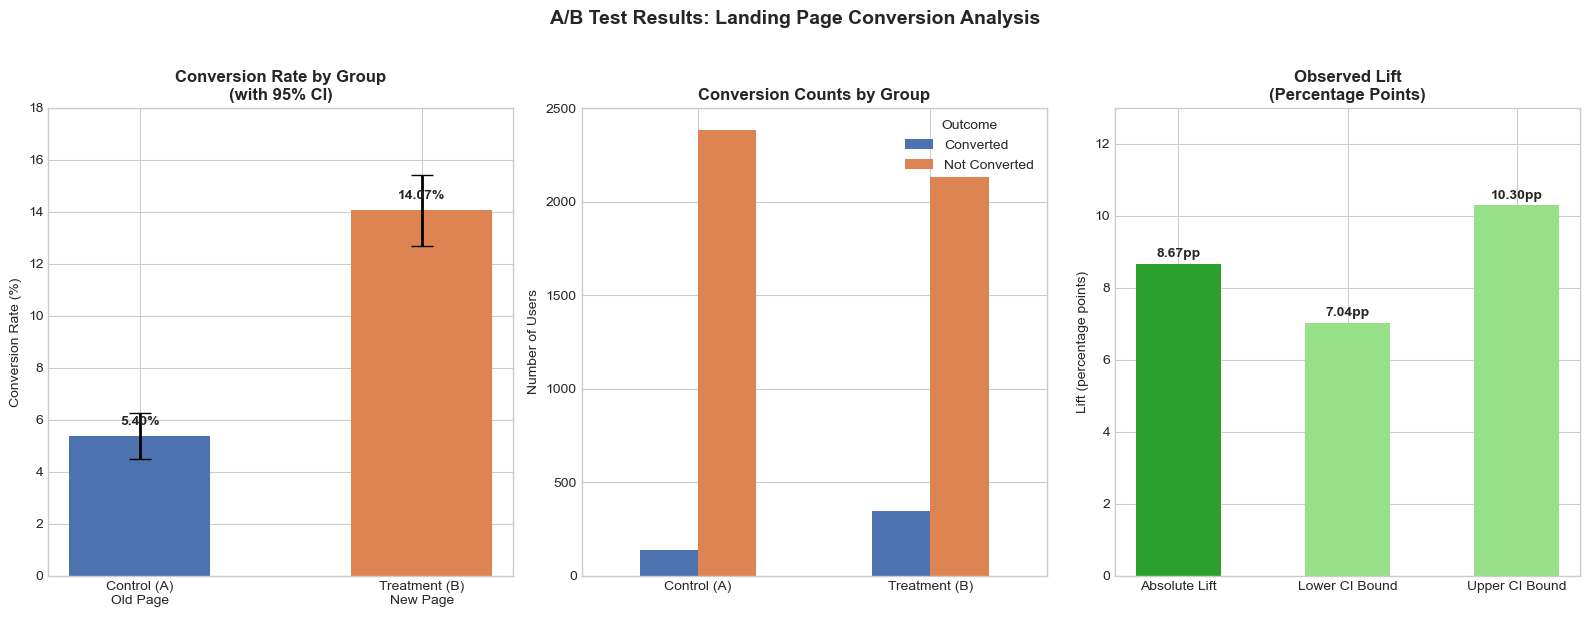

Chart saved as ab_test_results.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('A/B Test Results: Landing Page Conversion Analysis', fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Conversion rates with confidence intervals ---
groups = ['Control (A)\nOld Page', 'Treatment (B)\nNew Page']
rates = [p_a * 100, p_b * 100]
ci_errors = [
    (p_a - ci_a_low) * 100,
    (p_b - ci_b_low) * 100
]

bars = axes[0].bar(groups, rates, color=['#4C72B0', '#DD8452'], width=0.5, yerr=ci_errors,
                   capsize=8, error_kw={'linewidth': 2})
axes[0].set_title('Conversion Rate by Group\n(with 95% CI)', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 18)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Conversion counts (converted vs not) ---
conv_data = pd.DataFrame({
    'Group': ['Control (A)', 'Control (A)', 'Treatment (B)', 'Treatment (B)'],
    'Outcome': ['Converted', 'Not Converted', 'Converted', 'Not Converted'],
    'Count': [conv_a, n_a - conv_a, conv_b, n_b - conv_b]
})
conv_pivot = conv_data.pivot(index='Group', columns='Outcome', values='Count')
conv_pivot.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], width=0.5)
axes[1].set_title('Conversion Counts by Group', fontweight='bold')
axes[1].set_ylabel('Number of Users')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Outcome')

# --- Plot 3: Lift summary ---
categories = ['Absolute Lift', 'Lower CI Bound', 'Upper CI Bound']
values = [diff * 100, diff_ci_low * 100, diff_ci_high * 100]
colors = ['#2ca02c', '#98df8a', '#98df8a']
bars3 = axes[2].bar(categories, values, color=colors, width=0.5)
axes[2].set_title('Observed Lift\n(Percentage Points)', fontweight='bold')
axes[2].set_ylabel('Lift (percentage points)')
axes[2].set_ylim(0, 13)
for bar, val in zip(bars3, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}pp', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_results.png")

In [16]:
from scipy.stats import chi2_contingency

def segment_ab_test(df, segment_col):
    """Run z-test for each segment and return summary."""
    results = []
    segments = df[segment_col].unique()
    
    for segment in sorted(segments):
        seg = df[df[segment_col] == segment]
        seg_a = seg[seg['group'] == 'A']
        seg_b = seg[seg['group'] == 'B']
        
        n_a_seg = len(seg_a)
        n_b_seg = len(seg_b)
        conv_a_seg = seg_a['converted'].sum()
        conv_b_seg = seg_b['converted'].sum()
        
        rate_a = conv_a_seg / n_a_seg
        rate_b = conv_b_seg / n_b_seg
        lift = rate_b - rate_a
        
        # Z-test for this segment
        z, p = proportions_ztest(
            [conv_b_seg, conv_a_seg],
            [n_b_seg, n_a_seg],
            alternative='two-sided'
        )
        
        results.append({
            'segment': segment,
            'n_control': n_a_seg,
            'n_treatment': n_b_seg,
            'conv_rate_control': f"{rate_a:.2%}",
            'conv_rate_treatment': f"{rate_b:.2%}",
            'absolute_lift': f"{lift:.2%}",
            'p_value': round(p, 4),
            'significant': '✅' if p < 0.05 else '❌'
        })
    
    return pd.DataFrame(results).set_index('segment')

# --- Run segmentation ---
print("=" * 60)
print("SEGMENTATION BY DEVICE")
print("=" * 60)
device_results = segment_ab_test(df, 'device')
print(device_results.to_string())

print("\n")
print("=" * 60)
print("SEGMENTATION BY LOCATION")
print("=" * 60)
location_results = segment_ab_test(df, 'location')
print(location_results.to_string())

SEGMENTATION BY DEVICE
         n_control  n_treatment conv_rate_control conv_rate_treatment absolute_lift  p_value significant
segment                                                                                                 
Desktop       1244         1294             5.87%              13.91%         8.04%   0.0000           ✅
Mobile        1275         1187             4.94%              14.24%         9.30%   0.0000           ✅


SEGMENTATION BY LOCATION
                  n_control  n_treatment conv_rate_control conv_rate_treatment absolute_lift  p_value significant
segment                                                                                                          
England                 606          640             6.93%              14.69%         7.76%   0.0000           ✅
Northern Ireland        614          628             5.05%              11.46%         6.42%   0.0000           ✅
Scotland                670          611             4.93%              15

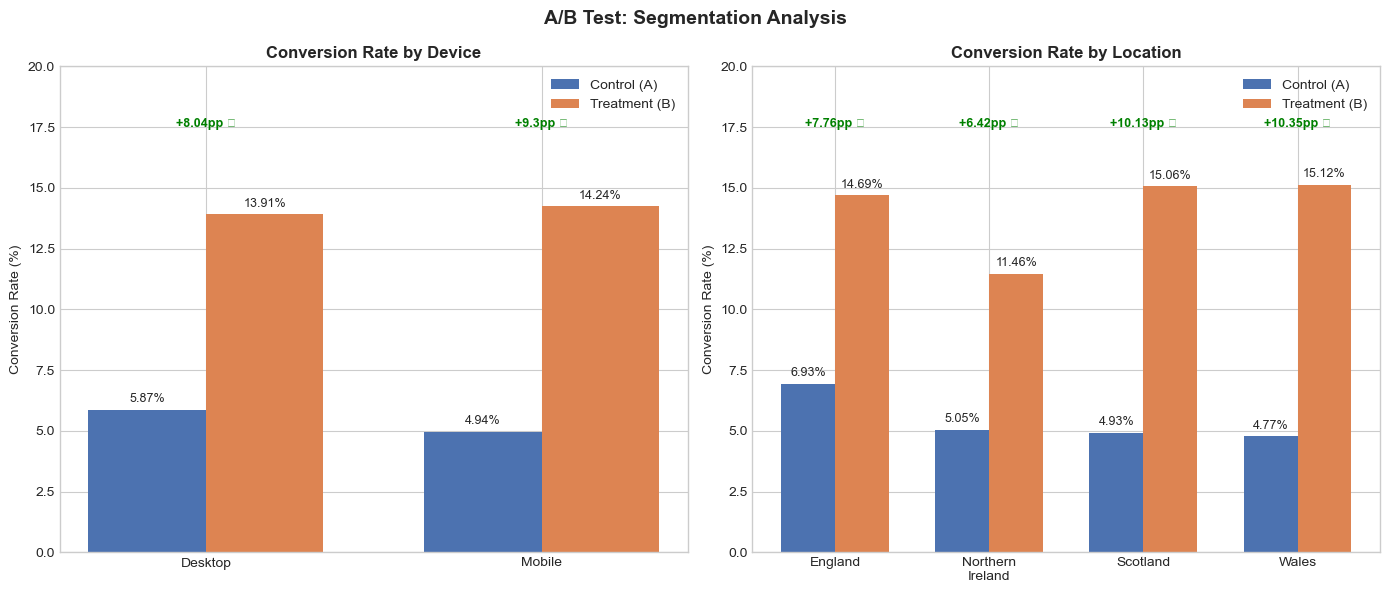

Segmentation chart saved as ab_test_segmentation.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('A/B Test: Segmentation Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: Device segmentation ---
device_segments = ['Desktop', 'Mobile']
control_rates_device = [5.87, 4.94]
treatment_rates_device = [13.91, 14.24]

x = np.arange(len(device_segments))
width = 0.35

bars1 = axes[0].bar(x - width/2, control_rates_device, width, 
                     label='Control (A)', color='#4C72B0')
bars2 = axes[0].bar(x + width/2, treatment_rates_device, width, 
                     label='Treatment (B)', color='#DD8452')

axes[0].set_title('Conversion Rate by Device', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(device_segments)
axes[0].set_ylim(0, 20)
axes[0].legend()

# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

# Add significance markers
for i, lift in enumerate([8.04, 9.30]):
    axes[0].text(i, 17.5, f'+{lift}pp ✅', ha='center', fontsize=9, 
                 color='green', fontweight='bold')

# --- Plot 2: Location segmentation ---
locations = ['England', 'Northern\nIreland', 'Scotland', 'Wales']
control_rates_loc = [6.93, 5.05, 4.93, 4.77]
treatment_rates_loc = [14.69, 11.46, 15.06, 15.12]
lifts_loc = [7.76, 6.42, 10.13, 10.35]

x2 = np.arange(len(locations))

bars3 = axes[1].bar(x2 - width/2, control_rates_loc, width,
                     label='Control (A)', color='#4C72B0')
bars4 = axes[1].bar(x2 + width/2, treatment_rates_loc, width,
                     label='Treatment (B)', color='#DD8452')

axes[1].set_title('Conversion Rate by Location', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(locations)
axes[1].set_ylim(0, 20)
axes[1].legend()

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

for i, lift in enumerate(lifts_loc):
    axes[1].text(i, 17.5, f'+{lift}pp ✅', ha='center', fontsize=9,
                 color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('ab_test_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segmentation chart saved as ab_test_segmentation.png")

BEHAVIOURAL PROFILE: CONVERTERS VS NON-CONVERTERS BY GROUP
                     n_users  avg_time_spent  median_time_spent  avg_page_views  median_page_views  std_time_spent
cohort                                                                                                            
A - Did Not Convert     2383        241.5200           240.0000          7.6100             8.0000        117.2100
A - Converted            136        245.3900           252.5000          7.1700             7.0000        119.9000
B - Did Not Convert     2132        243.4400           244.5000          7.5100             8.0000        119.6900
B - Converted            349        242.4400           242.0000          7.3700             7.0000        116.2600

--- T-Tests: Time Spent (Converters vs Non-Converters) ---
Group A: t = 0.3736, p = 0.7088 (not significant)
  Converter avg time:     245.4s
  Non-converter avg time: 241.5s
  Difference:             3.9s
Group B: t = -0.1453, p = 0.8845 (not signif

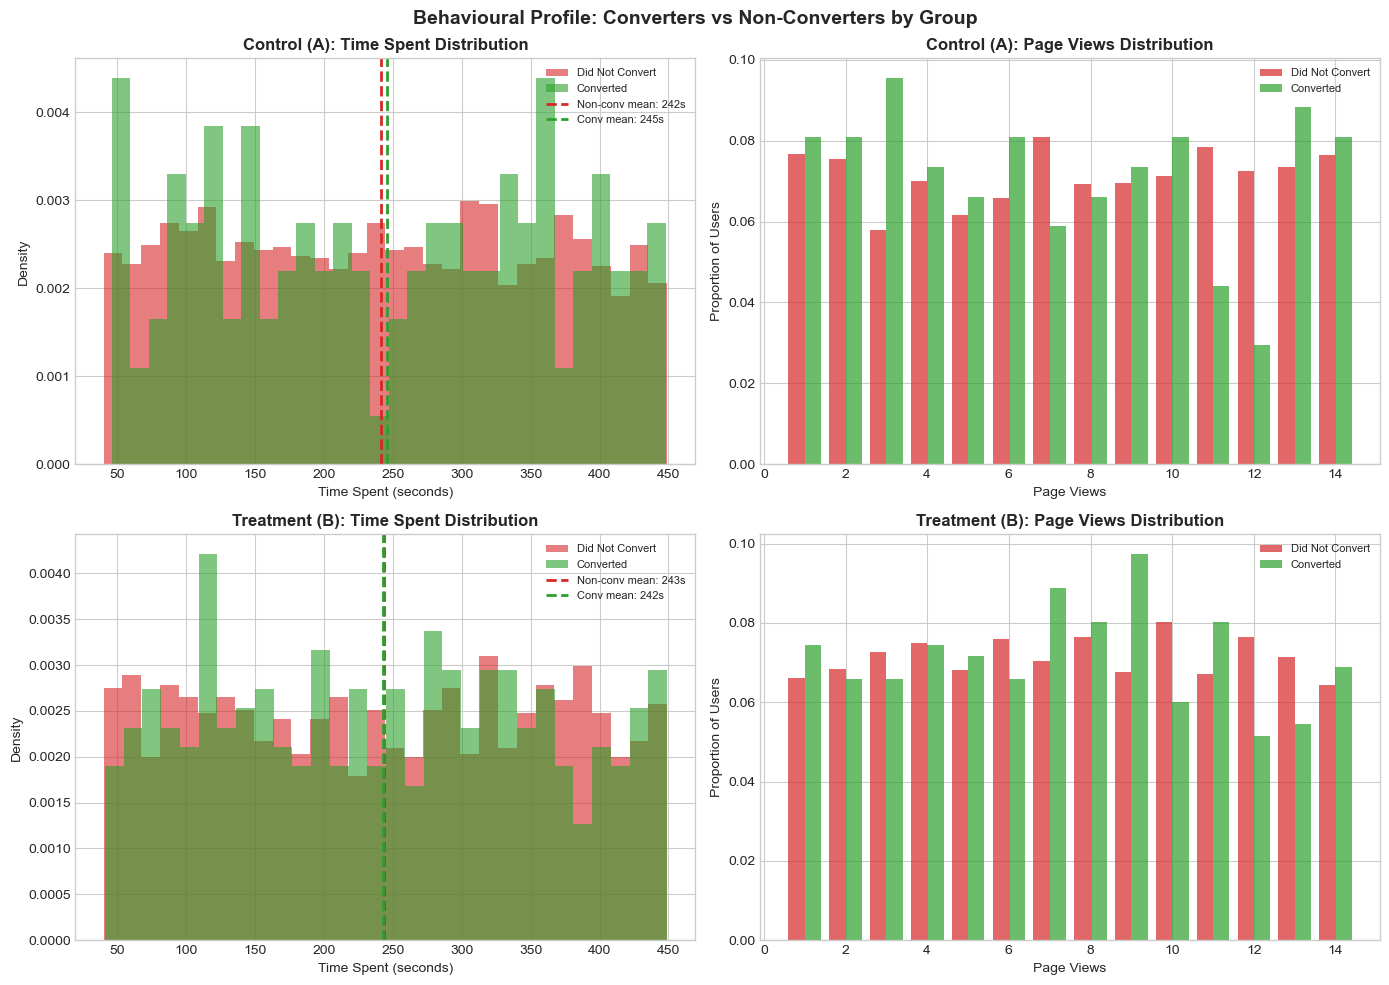

Chart saved as ab_test_behavioural_profile.png


In [20]:
# --- Analysis 1: Behavioural Profile by Group and Conversion Outcome ---

# Create four cohorts
cohorts = {
    'A - Did Not Convert': df[(df['group'] == 'A') & (df['converted'] == 0)],
    'A - Converted':       df[(df['group'] == 'A') & (df['converted'] == 1)],
    'B - Did Not Convert': df[(df['group'] == 'B') & (df['converted'] == 0)],
    'B - Converted':       df[(df['group'] == 'B') & (df['converted'] == 1)]
}

# Build summary table
profile_rows = []
for cohort_name, cohort_df in cohorts.items():
    profile_rows.append({
        'cohort': cohort_name,
        'n_users': len(cohort_df),
        'avg_time_spent': cohort_df['time_spent'].mean(),
        'median_time_spent': cohort_df['time_spent'].median(),
        'avg_page_views': cohort_df['page_views'].mean(),
        'median_page_views': cohort_df['page_views'].median(),
        'std_time_spent': cohort_df['time_spent'].std()
    })

profile_df = pd.DataFrame(profile_rows).set_index('cohort')
print("=" * 70)
print("BEHAVIOURAL PROFILE: CONVERTERS VS NON-CONVERTERS BY GROUP")
print("=" * 70)
print(profile_df.round(2).to_string())

# --- Statistical test: is time spent significantly different between ---
# --- converters and non-converters within each group? ---
print("\n--- T-Tests: Time Spent (Converters vs Non-Converters) ---")
for group in ['A', 'B']:
    conv = df[(df['group'] == group) & (df['converted'] == 1)]['time_spent']
    non_conv = df[(df['group'] == group) & (df['converted'] == 0)]['time_spent']
    t_stat, p_val = stats.ttest_ind(conv, non_conv)
    print(f"Group {group}: t = {t_stat:.4f}, p = {p_val:.4f} "
          f"({'significant' if p_val < 0.05 else 'not significant'})")
    print(f"  Converter avg time:     {conv.mean():.1f}s")
    print(f"  Non-converter avg time: {non_conv.mean():.1f}s")
    print(f"  Difference:             {conv.mean() - non_conv.mean():.1f}s")

print("\n--- T-Tests: Page Views (Converters vs Non-Converters) ---")
for group in ['A', 'B']:
    conv = df[(df['group'] == group) & (df['converted'] == 1)]['page_views']
    non_conv = df[(df['group'] == group) & (df['converted'] == 0)]['page_views']
    t_stat, p_val = stats.ttest_ind(conv, non_conv)
    print(f"Group {group}: t = {t_stat:.4f}, p = {p_val:.4f} "
          f"({'significant' if p_val < 0.05 else 'not significant'})")
    print(f"  Converter avg page views:     {conv.mean():.2f}")
    print(f"  Non-converter avg page views: {non_conv.mean():.2f}")
    print(f"  Difference:                   {conv.mean() - non_conv.mean():.2f}")

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Behavioural Profile: Converters vs Non-Converters by Group',
             fontsize=14, fontweight='bold')

colors = {'Converted': '#2ca02c', 'Did Not Convert': '#d62728'}

for idx, group in enumerate(['A', 'B']):
    group_label = 'Control (A)' if group == 'A' else 'Treatment (B)'
    conv_data = df[(df['group'] == group) & (df['converted'] == 1)]
    non_conv_data = df[(df['group'] == group) & (df['converted'] == 0)]

    # Time spent distribution
    axes[idx, 0].hist(non_conv_data['time_spent'], bins=30, alpha=0.6,
                      color='#d62728', label='Did Not Convert', density=True)
    axes[idx, 0].hist(conv_data['time_spent'], bins=30, alpha=0.6,
                      color='#2ca02c', label='Converted', density=True)
    axes[idx, 0].axvline(non_conv_data['time_spent'].mean(), color='#d62728',
                          linestyle='--', linewidth=2,
                          label=f'Non-conv mean: {non_conv_data["time_spent"].mean():.0f}s')
    axes[idx, 0].axvline(conv_data['time_spent'].mean(), color='#2ca02c',
                          linestyle='--', linewidth=2,
                          label=f'Conv mean: {conv_data["time_spent"].mean():.0f}s')
    axes[idx, 0].set_title(f'{group_label}: Time Spent Distribution', fontweight='bold')
    axes[idx, 0].set_xlabel('Time Spent (seconds)')
    axes[idx, 0].set_ylabel('Density')
    axes[idx, 0].legend(fontsize=8)

    # Page views distribution
    page_view_counts = sorted(df['page_views'].unique())
    non_conv_pv = non_conv_data['page_views'].value_counts(normalize=True).sort_index()
    conv_pv = conv_data['page_views'].value_counts(normalize=True).sort_index()

    axes[idx, 1].bar(np.array(list(non_conv_pv.index)) - 0.2,
                     non_conv_pv.values, width=0.4,
                     color='#d62728', alpha=0.7, label='Did Not Convert')
    axes[idx, 1].bar(np.array(list(conv_pv.index)) + 0.2,
                     conv_pv.values, width=0.4,
                     color='#2ca02c', alpha=0.7, label='Converted')
    axes[idx, 1].set_title(f'{group_label}: Page Views Distribution', fontweight='bold')
    axes[idx, 1].set_xlabel('Page Views')
    axes[idx, 1].set_ylabel('Proportion of Users')
    axes[idx, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('ab_test_behavioural_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_behavioural_profile.png")

ENGAGEMENT EFFICIENCY: CONVERTERS ONLY (A vs B)

Control (A) converters:   n = 136
Treatment (B) converters: n = 349

--- Time Spent at Conversion ---
Control (A):   mean = 245.4s  median = 252.5s  std = 119.9s
Treatment (B): mean = 242.4s  median = 242.0s  std = 116.3s
Difference:    -2.9s
T-test:        t = -0.2484, p = 0.8039 (not significant)

--- Page Views at Conversion ---
Control (A):   mean = 7.17  median = 7.0
Treatment (B): mean = 7.37  median = 7.0
Difference:    0.20 pages
T-test:        t = 0.4992, p = 0.6179 (not significant)

--- Mann-Whitney U Test (non-parametric confirmation) ---
Time spent:  U = 23388, p = 0.8040 (not significant)
Page views:  U = 24498, p = 0.5801 (not significant)

--- Time Spent Percentiles: Converters Only ---
     Control (A)  Treatment (B)
p10      88.0000        84.6000
p25     139.5000       140.0000
p50     252.5000       242.0000
p75     349.5000       337.0000
p90     407.0000       408.2000


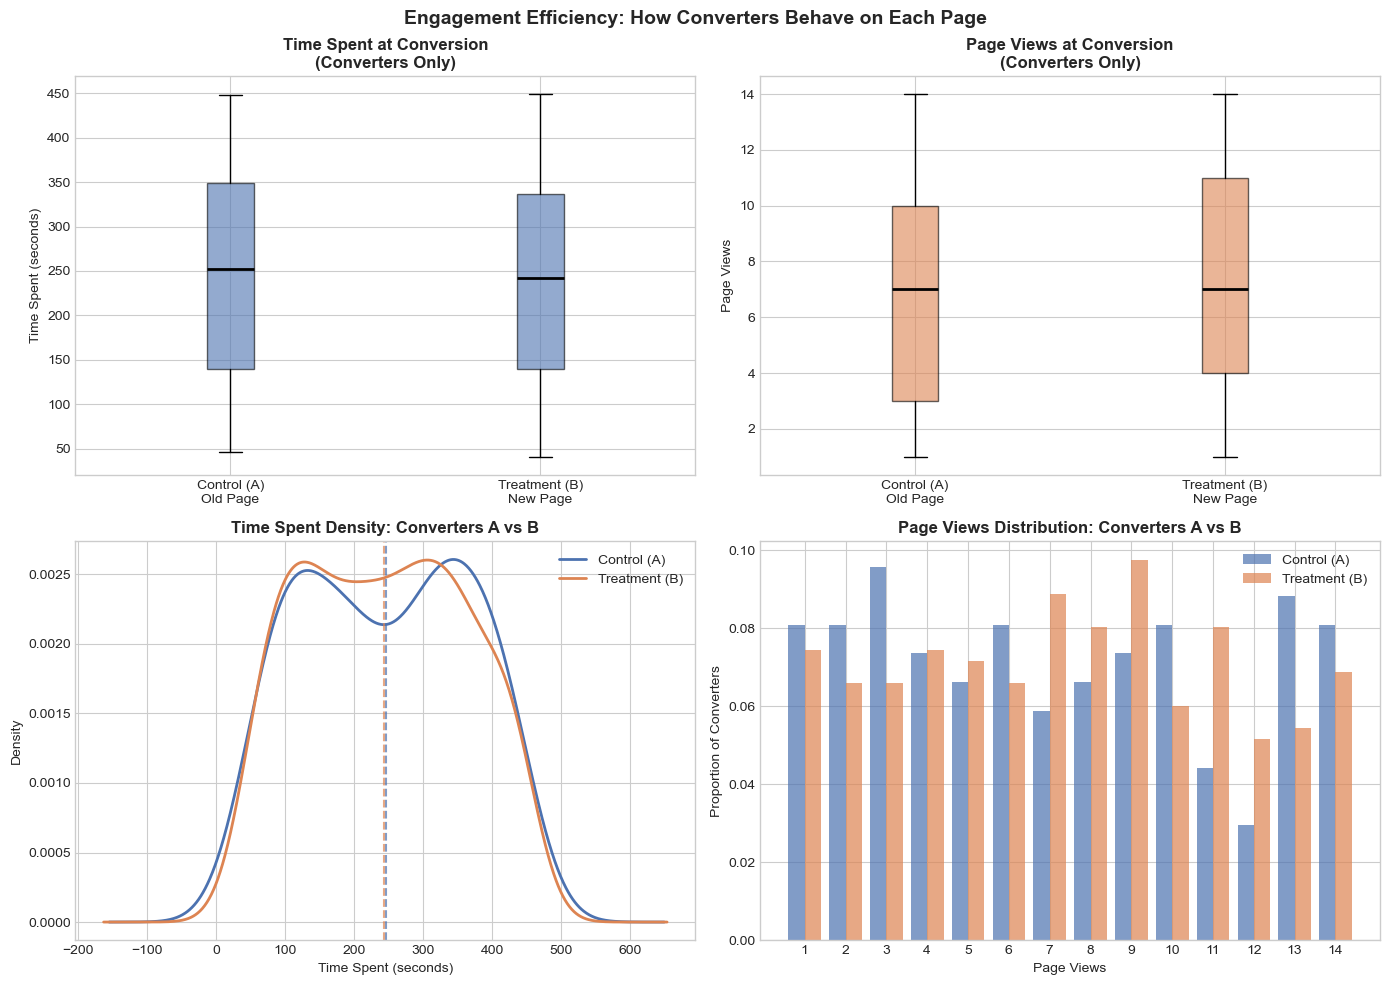

Chart saved as ab_test_efficiency.png


In [22]:
# --- Analysis 2: Engagement Efficiency ---
# Do converters on the new page behave differently from converters on the old page?
# A more persuasive page should lower the "cost" of conversion.

converters_a = df[(df['group'] == 'A') & (df['converted'] == 1)]
converters_b = df[(df['group'] == 'B') & (df['converted'] == 1)]

print("=" * 65)
print("ENGAGEMENT EFFICIENCY: CONVERTERS ONLY (A vs B)")
print("=" * 65)
print(f"\nControl (A) converters:   n = {len(converters_a)}")
print(f"Treatment (B) converters: n = {len(converters_b)}")

# --- Time spent comparison: converters only ---
t_stat_time, p_val_time = stats.ttest_ind(
    converters_b['time_spent'], converters_a['time_spent']
)
t_stat_pv, p_val_pv = stats.ttest_ind(
    converters_b['page_views'], converters_a['page_views']
)

print(f"\n--- Time Spent at Conversion ---")
print(f"Control (A):   mean = {converters_a['time_spent'].mean():.1f}s  "
      f"median = {converters_a['time_spent'].median():.1f}s  "
      f"std = {converters_a['time_spent'].std():.1f}s")
print(f"Treatment (B): mean = {converters_b['time_spent'].mean():.1f}s  "
      f"median = {converters_b['time_spent'].median():.1f}s  "
      f"std = {converters_b['time_spent'].std():.1f}s")
print(f"Difference:    {converters_b['time_spent'].mean() - converters_a['time_spent'].mean():.1f}s")
print(f"T-test:        t = {t_stat_time:.4f}, p = {p_val_time:.4f} "
      f"({'significant' if p_val_time < 0.05 else 'not significant'})")

print(f"\n--- Page Views at Conversion ---")
print(f"Control (A):   mean = {converters_a['page_views'].mean():.2f}  "
      f"median = {converters_a['page_views'].median():.1f}")
print(f"Treatment (B): mean = {converters_b['page_views'].mean():.2f}  "
      f"median = {converters_b['page_views'].median():.1f}")
print(f"Difference:    {converters_b['page_views'].mean() - converters_a['page_views'].mean():.2f} pages")
print(f"T-test:        t = {t_stat_pv:.4f}, p = {p_val_pv:.4f} "
      f"({'significant' if p_val_pv < 0.05 else 'not significant'})")

# --- Distribution comparison: Mann-Whitney U (non-parametric) ---
# Useful because converter sample sizes are small (136 vs 349)
# Mann-Whitney doesn't assume normality
print(f"\n--- Mann-Whitney U Test (non-parametric confirmation) ---")
u_stat_time, p_mw_time = stats.mannwhitneyu(
    converters_b['time_spent'], converters_a['time_spent'], alternative='two-sided'
)
u_stat_pv, p_mw_pv = stats.mannwhitneyu(
    converters_b['page_views'], converters_a['page_views'], alternative='two-sided'
)
print(f"Time spent:  U = {u_stat_time:.0f}, p = {p_mw_time:.4f} "
      f"({'significant' if p_mw_time < 0.05 else 'not significant'})")
print(f"Page views:  U = {u_stat_pv:.0f}, p = {p_mw_pv:.4f} "
      f"({'significant' if p_mw_pv < 0.05 else 'not significant'})")

# --- Percentile breakdown ---
print(f"\n--- Time Spent Percentiles: Converters Only ---")
percentiles = [10, 25, 50, 75, 90]
perc_df = pd.DataFrame({
    'Control (A)': [np.percentile(converters_a['time_spent'], p) for p in percentiles],
    'Treatment (B)': [np.percentile(converters_b['time_spent'], p) for p in percentiles]
}, index=[f'p{p}' for p in percentiles])
print(perc_df.round(1).to_string())

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engagement Efficiency: How Converters Behave on Each Page',
             fontsize=14, fontweight='bold')

# Plot 1: Time spent box plot — converters only
axes[0, 0].boxplot(
    [converters_a['time_spent'], converters_b['time_spent']],
    labels=['Control (A)\nOld Page', 'Treatment (B)\nNew Page'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[0, 0].set_title('Time Spent at Conversion\n(Converters Only)', fontweight='bold')
axes[0, 0].set_ylabel('Time Spent (seconds)')

# Plot 2: Page views box plot — converters only
axes[0, 1].boxplot(
    [converters_a['page_views'], converters_b['page_views']],
    labels=['Control (A)\nOld Page', 'Treatment (B)\nNew Page'],
    patch_artist=True,
    boxprops=dict(facecolor='#DD8452', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[0, 1].set_title('Page Views at Conversion\n(Converters Only)', fontweight='bold')
axes[0, 1].set_ylabel('Page Views')

# Plot 3: Time spent KDE overlay — converters only
converters_a['time_spent'].plot.kde(ax=axes[1, 0], color='#4C72B0',
                                     linewidth=2, label='Control (A)')
converters_b['time_spent'].plot.kde(ax=axes[1, 0], color='#DD8452',
                                     linewidth=2, label='Treatment (B)')
axes[1, 0].axvline(converters_a['time_spent'].mean(), color='#4C72B0',
                    linestyle='--', alpha=0.7)
axes[1, 0].axvline(converters_b['time_spent'].mean(), color='#DD8452',
                    linestyle='--', alpha=0.7)
axes[1, 0].set_title('Time Spent Density: Converters A vs B', fontweight='bold')
axes[1, 0].set_xlabel('Time Spent (seconds)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Plot 4: Page views comparison bar — converters only
pv_a = converters_a['page_views'].value_counts(normalize=True).sort_index()
pv_b = converters_b['page_views'].value_counts(normalize=True).sort_index()
all_pv = sorted(set(pv_a.index) | set(pv_b.index))
pv_a = pv_a.reindex(all_pv, fill_value=0)
pv_b = pv_b.reindex(all_pv, fill_value=0)

x = np.arange(len(all_pv))
axes[1, 1].bar(x - 0.2, pv_a.values, width=0.4, color='#4C72B0',
               alpha=0.7, label='Control (A)')
axes[1, 1].bar(x + 0.2, pv_b.values, width=0.4, color='#DD8452',
               alpha=0.7, label='Treatment (B)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(all_pv)
axes[1, 1].set_title('Page Views Distribution: Converters A vs B', fontweight='bold')
axes[1, 1].set_xlabel('Page Views')
axes[1, 1].set_ylabel('Proportion of Converters')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('ab_test_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_efficiency.png")

CONVERSION PROBABILITY BY ENGAGEMENT LEVEL

--- Conversion Rate by Time Spent Bin ---
          Control (A)  Treatment (B)  Lift (pp)
time_bin                                       
0-50s          0.0159         0.1127     9.6803
51-100s        0.0564         0.1331     7.6691
101-150s       0.0619         0.1498     8.7928
151-200s       0.0519         0.1503     9.8402
201-250s       0.0441         0.1511    10.7011
251-300s       0.0541         0.1433     8.9279
301-350s       0.0539         0.1494     9.5458
351-400s       0.0575         0.1162     5.8700
401-450s       0.0597         0.1413     8.1603

--- Conversion Rate by Page Views ---
            Control (A)  Treatment (B)  Lift (pp)
page_views                                       
1                0.0567         0.1557     9.8988
2                0.0576         0.1361     7.8503
3                0.0861         0.1292     4.3121
4                0.0565         0.1398     8.3288
5                0.0577         0.1471     8.93

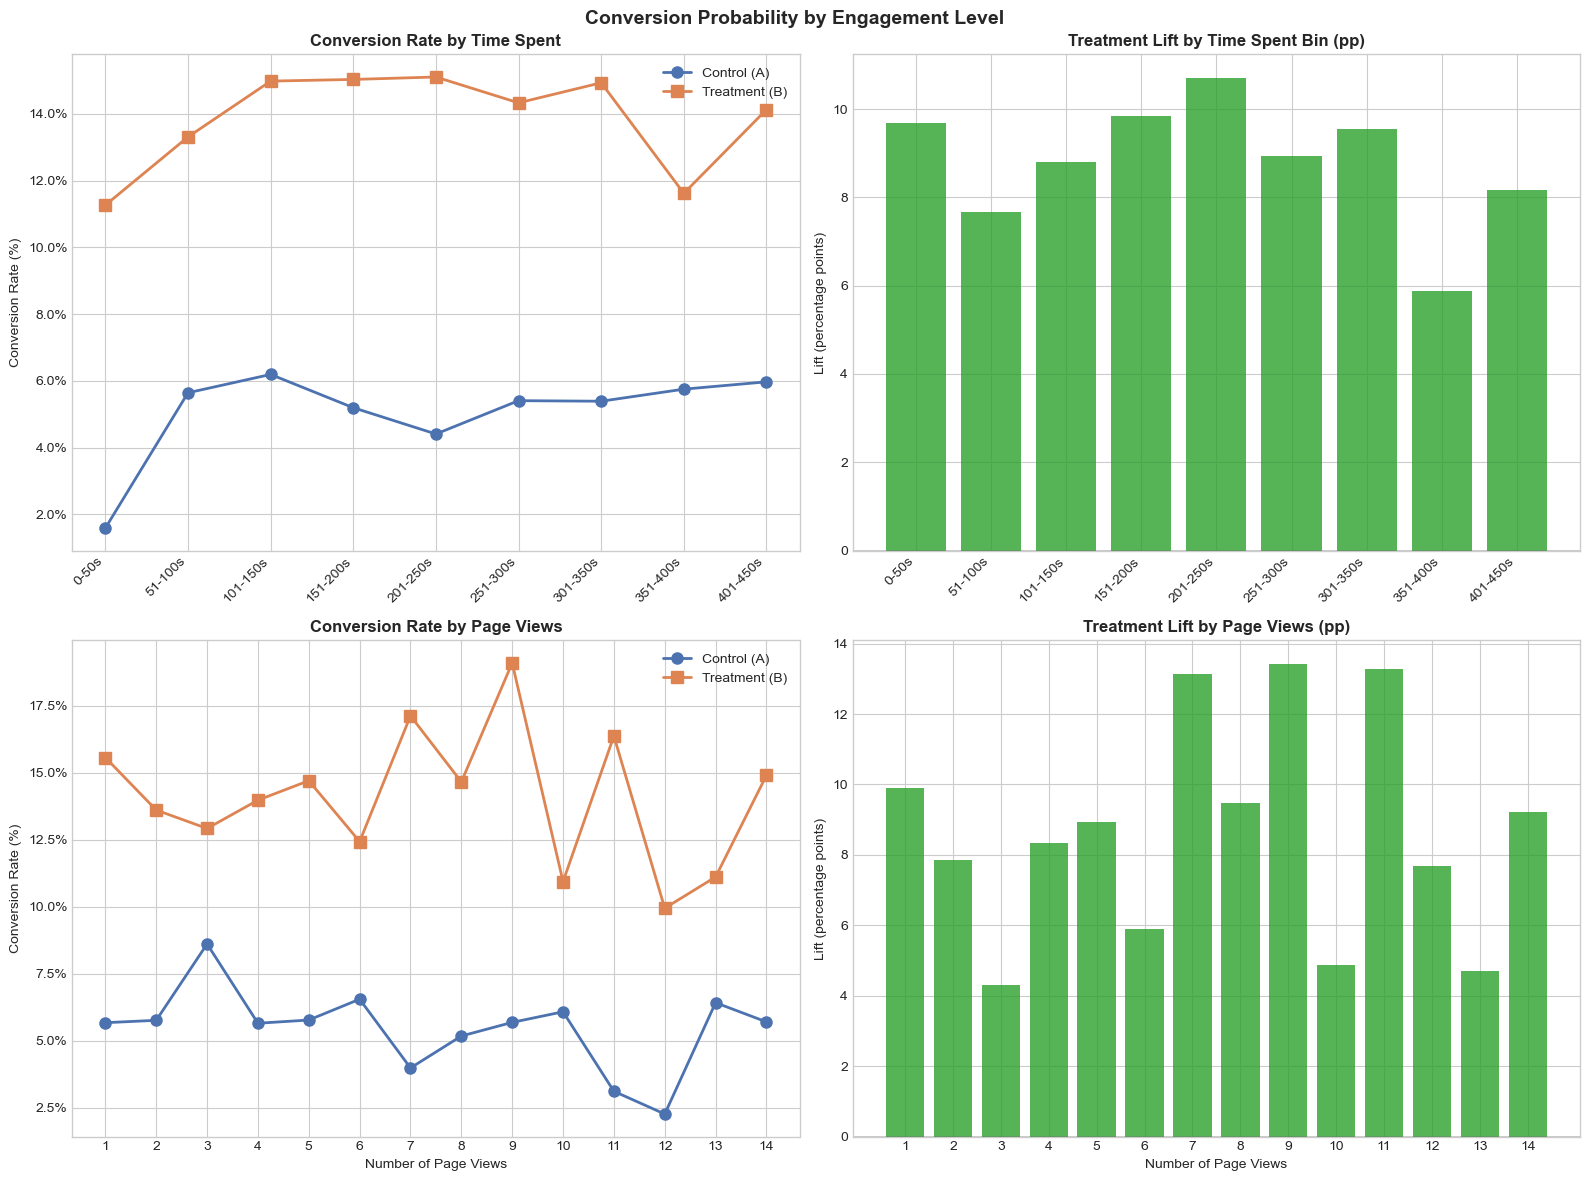

Chart saved as ab_test_engagement_threshold.png


In [24]:
# --- Analysis 3: Conversion Probability by Engagement Level ---
# Bin users by time spent and page views, calculate conversion rate within each bin
# Find the threshold where conversion probability accelerates

print("=" * 65)
print("CONVERSION PROBABILITY BY ENGAGEMENT LEVEL")
print("=" * 65)

# --- Part A: Conversion rate by time spent bins ---
# Create equal-width bins across the time range
time_bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]
time_labels = ['0-50s', '51-100s', '101-150s', '151-200s',
               '201-250s', '251-300s', '301-350s', '351-400s', '401-450s']

df['time_bin'] = pd.cut(df['time_spent'], bins=time_bins, labels=time_labels)

time_conv = df.groupby(['time_bin', 'group'], observed=True)['converted'].agg(
    ['sum', 'count', 'mean']
).reset_index()
time_conv.columns = ['time_bin', 'group', 'conversions', 'users', 'conv_rate']

print("\n--- Conversion Rate by Time Spent Bin ---")
time_pivot = time_conv.pivot(index='time_bin', columns='group', values='conv_rate')
time_pivot.columns = ['Control (A)', 'Treatment (B)']
time_pivot['Lift (pp)'] = (time_pivot['Treatment (B)'] - time_pivot['Control (A)']) * 100
print(time_pivot.round(4).to_string())

# --- Part B: Conversion rate by page views ---
print("\n--- Conversion Rate by Page Views ---")
pv_conv = df.groupby(['page_views', 'group'])['converted'].agg(
    ['sum', 'count', 'mean']
).reset_index()
pv_conv.columns = ['page_views', 'group', 'conversions', 'users', 'conv_rate']

pv_pivot = pv_conv.pivot(index='page_views', columns='group', values='conv_rate')
pv_pivot.columns = ['Control (A)', 'Treatment (B)']
pv_pivot['Lift (pp)'] = (pv_pivot['Treatment (B)'] - pv_pivot['Control (A)']) * 100
print(pv_pivot.round(4).to_string())

# --- Part C: Is the lift consistent across engagement levels? ---
# Or does treatment win more at high/low engagement?
print("\n--- Where is the lift largest? ---")
print("Time bins with largest Treatment lift:")
print(time_pivot.nlargest(3, 'Lift (pp)')[['Lift (pp)']].round(2))
print("\nTime bins with smallest Treatment lift:")
print(time_pivot.nsmallest(3, 'Lift (pp)')[['Lift (pp)']].round(2))

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Conversion Probability by Engagement Level',
             fontsize=14, fontweight='bold')

# Plot 1: Conversion rate by time bin, both groups
time_pivot_plot = time_pivot.reset_index()
axes[0, 0].plot(range(len(time_labels)),
                time_pivot['Control (A)'] * 100,
                marker='o', color='#4C72B0', linewidth=2,
                markersize=8, label='Control (A)')
axes[0, 0].plot(range(len(time_labels)),
                time_pivot['Treatment (B)'] * 100,
                marker='s', color='#DD8452', linewidth=2,
                markersize=8, label='Treatment (B)')
axes[0, 0].set_xticks(range(len(time_labels)))
axes[0, 0].set_xticklabels(time_labels, rotation=45, ha='right')
axes[0, 0].set_title('Conversion Rate by Time Spent', fontweight='bold')
axes[0, 0].set_ylabel('Conversion Rate (%)')
axes[0, 0].legend()
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# Plot 2: Lift by time bin
lift_colors = ['#2ca02c' if x > 0 else '#d62728' for x in time_pivot['Lift (pp)']]
axes[0, 1].bar(range(len(time_labels)), time_pivot['Lift (pp)'],
               color=lift_colors, alpha=0.8)
axes[0, 1].axhline(y=0, color='black', linewidth=1)
axes[0, 1].set_xticks(range(len(time_labels)))
axes[0, 1].set_xticklabels(time_labels, rotation=45, ha='right')
axes[0, 1].set_title('Treatment Lift by Time Spent Bin (pp)', fontweight='bold')
axes[0, 1].set_ylabel('Lift (percentage points)')

# Plot 3: Conversion rate by page views, both groups
pv_index = pv_pivot.index.tolist()
axes[1, 0].plot(pv_index,
                pv_pivot['Control (A)'] * 100,
                marker='o', color='#4C72B0', linewidth=2,
                markersize=8, label='Control (A)')
axes[1, 0].plot(pv_index,
                pv_pivot['Treatment (B)'] * 100,
                marker='s', color='#DD8452', linewidth=2,
                markersize=8, label='Treatment (B)')
axes[1, 0].set_xticks(pv_index)
axes[1, 0].set_title('Conversion Rate by Page Views', fontweight='bold')
axes[1, 0].set_ylabel('Conversion Rate (%)')
axes[1, 0].set_xlabel('Number of Page Views')
axes[1, 0].legend()
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# Plot 4: Lift by page views
pv_lifts = pv_pivot['Lift (pp)'].tolist()
lift_colors_pv = ['#2ca02c' if x > 0 else '#d62728' for x in pv_lifts]
axes[1, 1].bar(pv_index, pv_lifts, color=lift_colors_pv, alpha=0.8)
axes[1, 1].axhline(y=0, color='black', linewidth=1)
axes[1, 1].set_xticks(pv_index)
axes[1, 1].set_title('Treatment Lift by Page Views (pp)', fontweight='bold')
axes[1, 1].set_ylabel('Lift (percentage points)')
axes[1, 1].set_xlabel('Number of Page Views')

plt.tight_layout()
plt.savefig('ab_test_engagement_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_engagement_threshold.png")

ENGAGEMENT QUALITY: NON-CONVERTERS ONLY (A vs B)

Control (A) non-converters:   n = 2383
Treatment (B) non-converters: n = 2132

--- Time Spent: Non-Converters Only ---
Control (A):   mean = 241.5s  median = 240.0s  std = 117.2s
Treatment (B): mean = 243.4s  median = 244.5s  std = 119.7s
Difference:    1.9s
T-test:        t = 0.5440, p = 0.5864 (not significant)

--- Page Views: Non-Converters Only ---
Control (A):   mean = 7.61  median = 8.0
Treatment (B): mean = 7.51  median = 8.0
Difference:    -0.09 pages
T-test:        t = -0.7661, p = 0.4437 (not significant)

--- Mann-Whitney U Confirmation ---
Time spent:  U = 2564170, p = 0.5848 (not significant)
Page views:  U = 2505948, p = 0.4312 (not significant)

--- Time Spent Percentiles: Non-Converters Only ---
     Control (A)  Treatment (B)  Difference
p10      81.0000        80.0000     -1.0000
p25     137.5000       136.0000     -1.5000
p50     240.0000       244.5000      4.5000
p75     342.0000       349.0000      7.0000
p90     

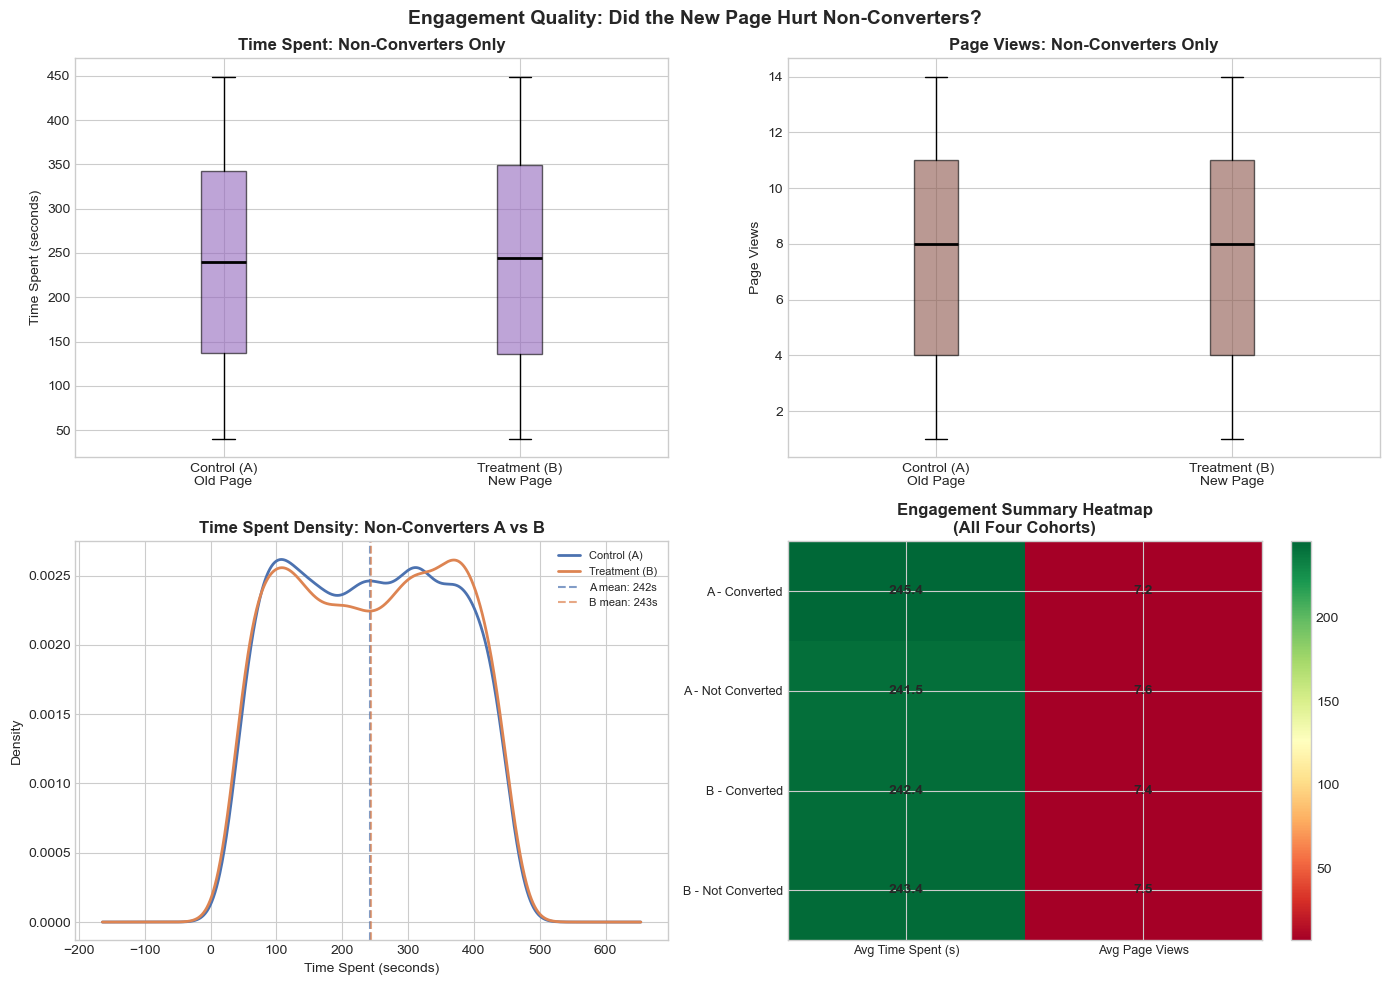

Chart saved as ab_test_engagement_quality.png


In [26]:
# --- Analysis 4: Did the new page hurt engagement for non-converters? ---
# A page optimised aggressively for conversion can sometimes feel pushy
# or low-quality, causing non-converters to disengage faster.
# If non-converters on B spent less time than non-converters on A,
# that's a brand/SEO risk worth flagging even if conversion went up.

non_conv_a = df[(df['group'] == 'A') & (df['converted'] == 0)]
non_conv_b = df[(df['group'] == 'B') & (df['converted'] == 0)]

print("=" * 65)
print("ENGAGEMENT QUALITY: NON-CONVERTERS ONLY (A vs B)")
print("=" * 65)
print(f"\nControl (A) non-converters:   n = {len(non_conv_a)}")
print(f"Treatment (B) non-converters: n = {len(non_conv_b)}")

# --- Time spent comparison: non-converters only ---
t_stat_time, p_val_time = stats.ttest_ind(
    non_conv_b['time_spent'], non_conv_a['time_spent']
)
t_stat_pv, p_val_pv = stats.ttest_ind(
    non_conv_b['page_views'], non_conv_a['page_views']
)

print(f"\n--- Time Spent: Non-Converters Only ---")
print(f"Control (A):   mean = {non_conv_a['time_spent'].mean():.1f}s  "
      f"median = {non_conv_a['time_spent'].median():.1f}s  "
      f"std = {non_conv_a['time_spent'].std():.1f}s")
print(f"Treatment (B): mean = {non_conv_b['time_spent'].mean():.1f}s  "
      f"median = {non_conv_b['time_spent'].median():.1f}s  "
      f"std = {non_conv_b['time_spent'].std():.1f}s")
print(f"Difference:    {non_conv_b['time_spent'].mean() - non_conv_a['time_spent'].mean():.1f}s")
print(f"T-test:        t = {t_stat_time:.4f}, p = {p_val_time:.4f} "
      f"({'significant' if p_val_time < 0.05 else 'not significant'})")

print(f"\n--- Page Views: Non-Converters Only ---")
print(f"Control (A):   mean = {non_conv_a['page_views'].mean():.2f}  "
      f"median = {non_conv_a['page_views'].median():.1f}")
print(f"Treatment (B): mean = {non_conv_b['page_views'].mean():.2f}  "
      f"median = {non_conv_b['page_views'].median():.1f}")
print(f"Difference:    {non_conv_b['page_views'].mean() - non_conv_a['page_views'].mean():.2f} pages")
print(f"T-test:        t = {t_stat_pv:.4f}, p = {p_val_pv:.4f} "
      f"({'significant' if p_val_pv < 0.05 else 'not significant'})")

# --- Mann-Whitney confirmation ---
u_stat_time, p_mw_time = stats.mannwhitneyu(
    non_conv_b['time_spent'], non_conv_a['time_spent'], alternative='two-sided'
)
u_stat_pv, p_mw_pv = stats.mannwhitneyu(
    non_conv_b['page_views'], non_conv_a['page_views'], alternative='two-sided'
)
print(f"\n--- Mann-Whitney U Confirmation ---")
print(f"Time spent:  U = {u_stat_time:.0f}, p = {p_mw_time:.4f} "
      f"({'significant' if p_mw_time < 0.05 else 'not significant'})")
print(f"Page views:  U = {u_stat_pv:.0f}, p = {p_mw_pv:.4f} "
      f"({'significant' if p_mw_pv < 0.05 else 'not significant'})")

# --- Percentile breakdown ---
print(f"\n--- Time Spent Percentiles: Non-Converters Only ---")
percentiles = [10, 25, 50, 75, 90]
perc_df = pd.DataFrame({
    'Control (A)': [np.percentile(non_conv_a['time_spent'], p) for p in percentiles],
    'Treatment (B)': [np.percentile(non_conv_b['time_spent'], p) for p in percentiles],
}, index=[f'p{p}' for p in percentiles])
perc_df['Difference'] = perc_df['Treatment (B)'] - perc_df['Control (A)']
print(perc_df.round(1).to_string())

# --- Overall engagement summary table ---
print(f"\n--- Full Engagement Summary ---")
summary = pd.DataFrame({
    'Group': ['Control (A)', 'Control (A)', 'Treatment (B)', 'Treatment (B)'],
    'Cohort': ['Converted', 'Not Converted', 'Converted', 'Not Converted'],
    'n': [len(converters_a), len(non_conv_a), len(converters_b), len(non_conv_b)],
    'Avg Time Spent': [
        converters_a['time_spent'].mean(),
        non_conv_a['time_spent'].mean(),
        converters_b['time_spent'].mean(),
        non_conv_b['time_spent'].mean()
    ],
    'Avg Page Views': [
        converters_a['page_views'].mean(),
        non_conv_a['page_views'].mean(),
        converters_b['page_views'].mean(),
        non_conv_b['page_views'].mean()
    ]
}).set_index(['Group', 'Cohort'])
print(summary.round(2).to_string())

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engagement Quality: Did the New Page Hurt Non-Converters?',
             fontsize=14, fontweight='bold')

# Plot 1: Time spent box plot — non-converters only
axes[0, 0].boxplot(
    [non_conv_a['time_spent'], non_conv_b['time_spent']],
    labels=['Control (A)\nOld Page', 'Treatment (B)\nNew Page'],
    patch_artist=True,
    boxprops=dict(facecolor='#9467bd', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[0, 0].set_title('Time Spent: Non-Converters Only', fontweight='bold')
axes[0, 0].set_ylabel('Time Spent (seconds)')

# Plot 2: Page views box plot — non-converters only
axes[0, 1].boxplot(
    [non_conv_a['page_views'], non_conv_b['page_views']],
    labels=['Control (A)\nOld Page', 'Treatment (B)\nNew Page'],
    patch_artist=True,
    boxprops=dict(facecolor='#8c564b', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[0, 1].set_title('Page Views: Non-Converters Only', fontweight='bold')
axes[0, 1].set_ylabel('Page Views')

# Plot 3: KDE — non-converters time spent
non_conv_a['time_spent'].plot.kde(ax=axes[1, 0], color='#4C72B0',
                                   linewidth=2, label='Control (A)')
non_conv_b['time_spent'].plot.kde(ax=axes[1, 0], color='#DD8452',
                                   linewidth=2, label='Treatment (B)')
axes[1, 0].axvline(non_conv_a['time_spent'].mean(), color='#4C72B0',
                    linestyle='--', alpha=0.7,
                    label=f"A mean: {non_conv_a['time_spent'].mean():.0f}s")
axes[1, 0].axvline(non_conv_b['time_spent'].mean(), color='#DD8452',
                    linestyle='--', alpha=0.7,
                    label=f"B mean: {non_conv_b['time_spent'].mean():.0f}s")
axes[1, 0].set_title('Time Spent Density: Non-Converters A vs B', fontweight='bold')
axes[1, 0].set_xlabel('Time Spent (seconds)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend(fontsize=8)

# Plot 4: Full 2x2 summary heatmap
summary_heatmap = pd.DataFrame({
    'Avg Time Spent (s)': [
        converters_a['time_spent'].mean(),
        non_conv_a['time_spent'].mean(),
        converters_b['time_spent'].mean(),
        non_conv_b['time_spent'].mean()
    ],
    'Avg Page Views': [
        converters_a['page_views'].mean(),
        non_conv_a['page_views'].mean(),
        converters_b['page_views'].mean(),
        non_conv_b['page_views'].mean()
    ]
}, index=['A - Converted', 'A - Not Converted',
          'B - Converted', 'B - Not Converted'])

im = axes[1, 1].imshow(summary_heatmap.values, cmap='RdYlGn', aspect='auto')
axes[1, 1].set_xticks(range(len(summary_heatmap.columns)))
axes[1, 1].set_xticklabels(summary_heatmap.columns, fontsize=9)
axes[1, 1].set_yticks(range(len(summary_heatmap.index)))
axes[1, 1].set_yticklabels(summary_heatmap.index, fontsize=9)
axes[1, 1].set_title('Engagement Summary Heatmap\n(All Four Cohorts)', fontweight='bold')
for i in range(len(summary_heatmap.index)):
    for j in range(len(summary_heatmap.columns)):
        axes[1, 1].text(j, i, f'{summary_heatmap.values[i, j]:.1f}',
                        ha='center', va='center', fontweight='bold', fontsize=10)
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('ab_test_engagement_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_engagement_quality.png")

In [28]:
print("""
=============================================================
BUSINESS RECOMMENDATION
=============================================================

DECISION: SHIP THE NEW LANDING PAGE — FULL ROLLOUT

-------------------------------------------------------------
HEADLINE RESULTS
-------------------------------------------------------------
  Conversion rate:    5.40% → 14.07%
  Absolute lift:      +8.67 percentage points
  Relative lift:      +160.5%
  95% CI:             [7.04pp – 10.30pp]
  P-value:            < 0.001
  Effect size:        Cohen's h = 0.30 (medium)

The result is statistically significant. The confidence
interval sits entirely above zero, ruling out a chance
finding at the 95% level. The experiment was well-powered —
it needed 175 users per group to detect this effect; it had
2,481.

-------------------------------------------------------------
WHY THE RESULT IS TRUSTWORTHY
-------------------------------------------------------------
  - 50.38% / 49.62% group split — no assignment bias
  - Zero duplicate users — no contamination
  - Device and location balanced across both groups
  - Sample size exceeded minimum requirement by 14x

-------------------------------------------------------------
SEGMENTATION: THE LIFT IS UNIVERSAL
-------------------------------------------------------------
  The new page outperforms the old across every segment
  tested. No group was left behind.

  By device:
    Desktop:          5.87% → 13.91%  (+8.04pp)
    Mobile:           4.94% → 14.24%  (+9.30pp)

  By location:
    England:          6.93% → 14.69%  (+7.76pp)
    Northern Ireland: 5.05% → 11.46%  (+6.42pp)
    Scotland:         4.93% → 15.06%  (+10.13pp)
    Wales:            4.77% → 15.12%  (+10.35pp)

  A full rollout carries no known risk of harming any
  user segment.

-------------------------------------------------------------
BEHAVIOURAL FINDINGS: WHAT IS DRIVING THE LIFT
-------------------------------------------------------------
  Four deeper analyses were run beyond conversion rate.
  All four point to the same conclusion.

  1. Conversion is independent of engagement depth.
     Converters and non-converters in both groups spent
     identical time on site and viewed identical numbers
     of pages. The page element driving conversion is
     triggering decisions regardless of browsing depth.

  2. The new page did not change how converters behave.
     Converters on B spent 242s on site vs 245s for A
     (p = 0.80). The new page converted more people,
     not a different type of person.

  3. The lift holds across all engagement levels.
     Conversion probability on the old page was flat
     regardless of time spent. The new page starts
     higher and stays higher across every time bin,
     with the strongest gains among quick deciders
     (0-50s: +9.68pp) and mid-range browsers
     (201-250s: +10.70pp).

  4. Non-converter experience was not degraded.
     Users who did not convert on the new page spent
     243s on site vs 242s on the old page (p = 0.59).
     The new page does not use engagement-destroying
     tactics to force conversions.

  The combined picture: a specific element on the new
  page — most likely the CTA, offer framing, or trust
  signals — is triggering purchase decisions the old
  page failed to trigger, at no cost to user experience.

-------------------------------------------------------------
CAVEATS
-------------------------------------------------------------
  1. Synthetic dataset. The 160% relative lift is
     unrealistic for production e-commerce (typical
     wins: 2-15% relative). Methodology is valid;
     magnitude should not be taken at face value.

  2. No revenue data. Conversion rate improvement is
     confirmed but average order value is unknown.
     Post-rollout revenue monitoring is advised.

  3. Experiment duration unknown. If the test ran for
     less than two full business cycles, novelty
     effect cannot be ruled out.

-------------------------------------------------------------
RECOMMENDED NEXT STEPS
-------------------------------------------------------------
  1. Ship the new page to 100% of traffic immediately.

  2. Monitor conversion rate and revenue weekly for
     4 weeks post-rollout to confirm the lift holds
     outside experimental conditions.

  3. Run a follow-up element-level test. Since
     behavioural data shows conversion is independent
     of engagement depth, the driver is almost
     certainly a single page element. Test the CTA,
     offer block, and trust signals in isolation to
     identify and amplify the exact driver.

  4. Investigate Scotland and Wales. Both regions
     showed lifts above 10pp vs 6-8pp elsewhere.
     Understanding why could unlock region-specific
     optimisation opportunities.

  5. Track non-converter return rate post-rollout.
     Since non-converter engagement was preserved,
     users who did not buy on first visit remain
     warm prospects. A retargeting strategy for
     this segment could compound the gains from
     the page change.

=============================================================
""")


BUSINESS RECOMMENDATION

DECISION: SHIP THE NEW LANDING PAGE — FULL ROLLOUT

-------------------------------------------------------------
HEADLINE RESULTS
-------------------------------------------------------------
  Conversion rate:    5.40% → 14.07%
  Absolute lift:      +8.67 percentage points
  Relative lift:      +160.5%
  95% CI:             [7.04pp – 10.30pp]
  P-value:            < 0.001
  Effect size:        Cohen's h = 0.30 (medium)

The result is statistically significant. The confidence
interval sits entirely above zero, ruling out a chance
finding at the 95% level. The experiment was well-powered —
it needed 175 users per group to detect this effect; it had
2,481.

-------------------------------------------------------------
WHY THE RESULT IS TRUSTWORTHY
-------------------------------------------------------------
  - 50.38% / 49.62% group split — no assignment bias
  - Zero duplicate users — no contamination
  - Device and location balanced across both groups
  - Sa